In [1]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive/')
df = pd.read_csv("/content/drive/My Drive/COS351/COS351 final project/full_companies_dataset.csv")

Mounted at /content/drive/


In [2]:
df = df.drop(['group_member', 'notes'], axis=1)

In [3]:
# converting to binary data
def encode_and_bind(original_dataframe, feature_to_encode):
    dummies = pd.get_dummies(original_dataframe[[feature_to_encode]])
    res = pd.concat([original_dataframe, dummies], axis=1)
    res = res.drop([feature_to_encode], axis=1)
    return(res)

one_hot_labels = ["sector", "sub_sector", "size_bucket"]
for label in one_hot_labels:
  df = encode_and_bind(df, label)

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# fill in missing revenues
df.at[20, 'revenue_b'] = 4.91
df.at[42, 'revenue_b'] = 125
df['revenue_b'] = scaler.fit_transform(df[['revenue_b']])

Text(0.5, 1.0, 'Hierarchical Clustering of All Companies')

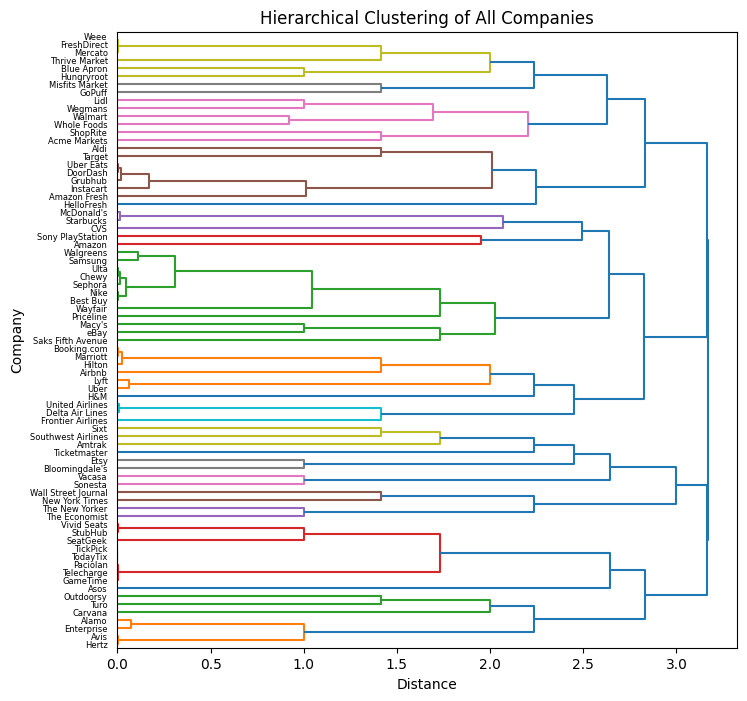

In [5]:
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
%matplotlib inline

# hierarchical clustering

companies = df['company']
X = df.drop(['company'],axis=1)
Z = hierarchy.linkage(X.to_numpy(), 'complete')

plt.figure(figsize=(8,8))
dn = hierarchy.dendrogram(Z,labels=companies.tolist(),orientation='right')
plt.xlabel("Distance")
plt.ylabel("Company")
plt.title("Hierarchical Clustering of All Companies")

Text(0.5, 1.0, 'Hierarchical Clustering of All Companies (Without Disclosure Status)')

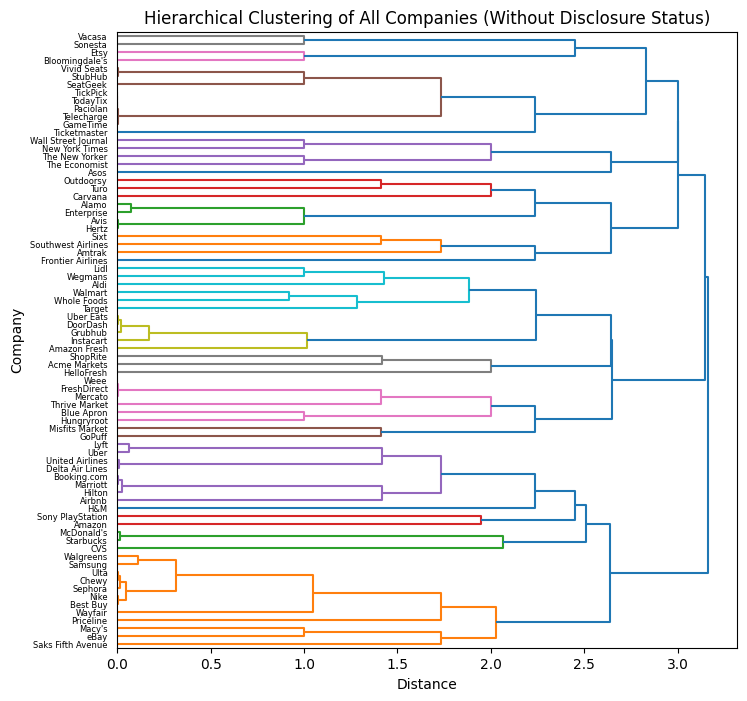

In [8]:
# hierarchical clustering without disclosure

companies = df['company']
X = df.drop(['company', 'disclosure'],axis=1)
Z = hierarchy.linkage(X.to_numpy(), 'complete')

plt.figure(figsize=(8,8))
dn = hierarchy.dendrogram(Z,labels=companies.tolist(),orientation='right')
plt.xlabel("Distance")
plt.ylabel("Company")
plt.title("Hierarchical Clustering of All Companies (Without Disclosure Status)")

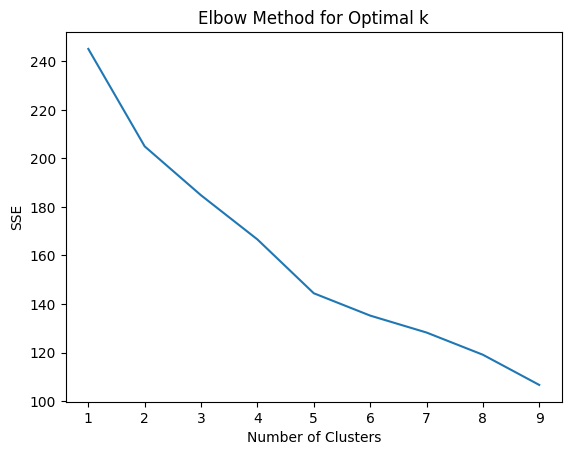

In [43]:
# k means clustering
from sklearn import cluster

# determine optimal number of clusters for k-means clustering
def get_best_k_clusters(data, max_k=10):
  SSE = []
  for k in range(1,max_k):
      k_means = cluster.KMeans(n_clusters=k)
      k_means.fit(data)
      SSE.append(k_means.inertia_)

  plt.plot(range(1,max_k), SSE)
  plt.xlabel('Number of Clusters')
  plt.ylabel('SSE')
  plt.title('Elbow Method for Optimal k')

cluster_data = df.drop('company',axis=1)
get_best_k_clusters(cluster_data)

In [41]:
k_means = cluster.KMeans(n_clusters=5, max_iter=50, random_state=1)
k_means.fit(cluster_data)
labels = k_means.labels_
pd.DataFrame(labels, index=df.company, columns=['Cluster ID'])

,Cluster ID
company,
Bloomingdale's,1
eBay,1
Etsy,1
Macy's,1
Saks Fifth Avenue,1
...,...
TodayTix,4
Paciolan,4
TickPick,4


In [37]:
from sklearn.decomposition import PCA
import numpy as np

# PCA: reduce high dimensional data to d=2
df_no_company = df.drop("company", axis=1)
pca_2 = PCA(n_components=2)
pca_2_result = pca_2.fit_transform(df_no_company)
print('Explained variation per principal component: {}'.format(pca_2.explained_variance_ratio_))

print('Cumulative variance explained by 2 principal components: {:.2%}'.format(np.sum(pca_2.explained_variance_ratio_)))


Explained variation per principal component: [0.19871868 0.14898891]
Cumulative variance explained by 2 principal components: 34.77%


In [12]:
!pip install adjustText

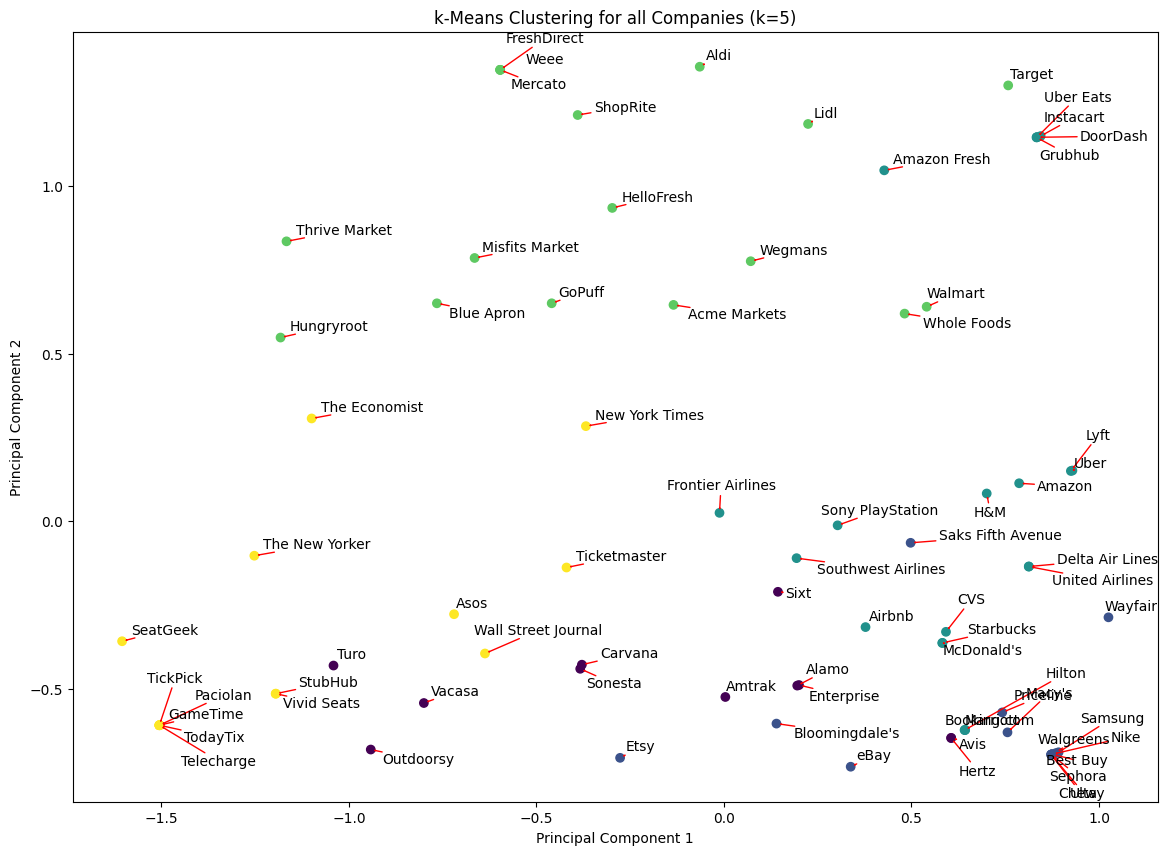

In [42]:
from adjustText import adjust_text

def visualize_clusters(results, labels, k):
  plt.figure(figsize=(14, 10))
  plt.scatter(results[:, 0], results[:, 1], c=labels)
  texts = []
  for x, y, company in zip(results[:, 0], results[:, 1], df.company):
      texts.append(plt.text(x, y, company))

  # This one line handles all the magic of preventing overlaps!
  adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'), expand=(1.5, 1.5))
  plt.title(f'k-Means Clustering for all Companies (k={k})')
  plt.xlabel('Principal Component 1')
  plt.ylabel('Principal Component 2')

visualize_clusters(pca_2_result, labels, 5)


Explained variation per principal component: [0.2046972  0.14635268]
Cumulative variance explained by 2 principal components: 35.10%


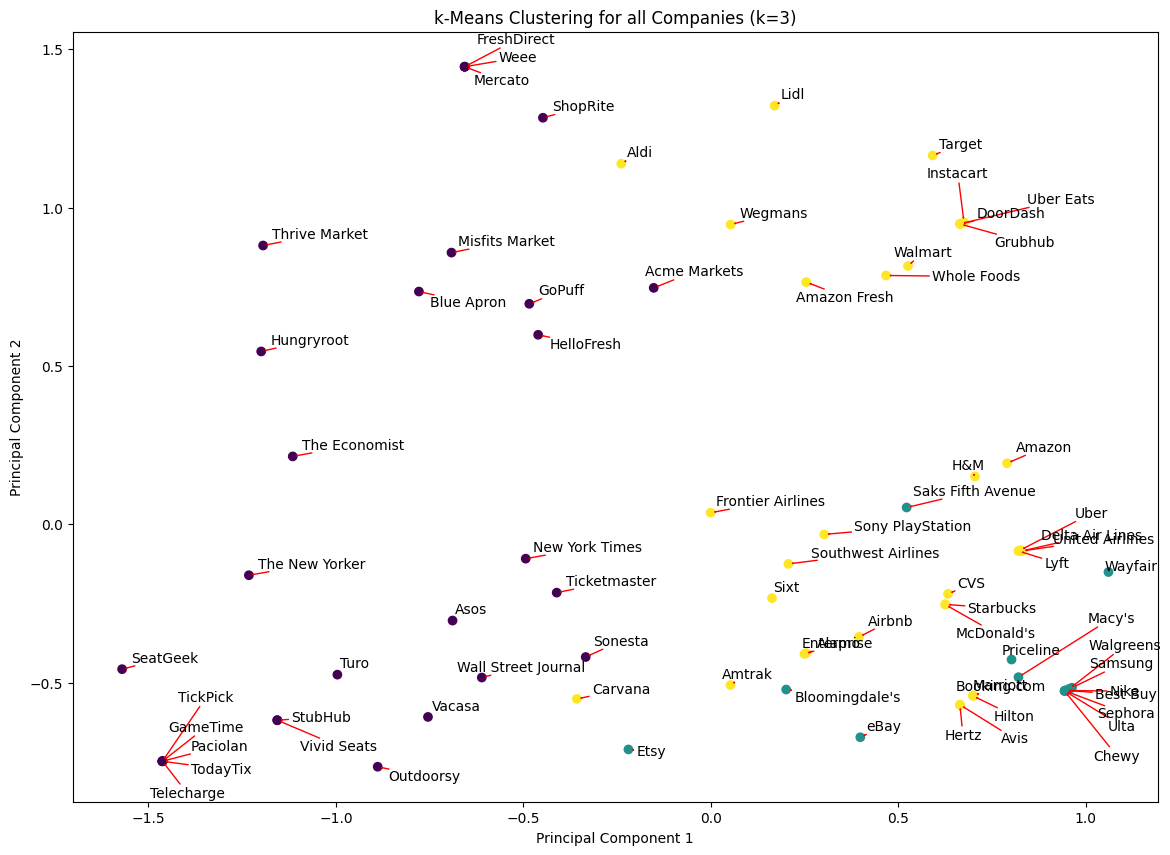

In [20]:
# remove disclosure presence column
df1 = df.drop(["company", "disclosure"], axis=1)

pca_2_1 = PCA(n_components=2)
pca_2_result_1 = pca_2_1.fit_transform(df1)
print('Explained variation per principal component: {}'.format(pca_2_1.explained_variance_ratio_))

print('Cumulative variance explained by 2 principal components: {:.2%}'.format(np.sum(pca_2_1.explained_variance_ratio_)))
visualize_clusters(pca_2_result_1, labels)

Explained variation per principal component: [0.2046972  0.14635268]
Cumulative variance explained by 2 principal components: 35.10%


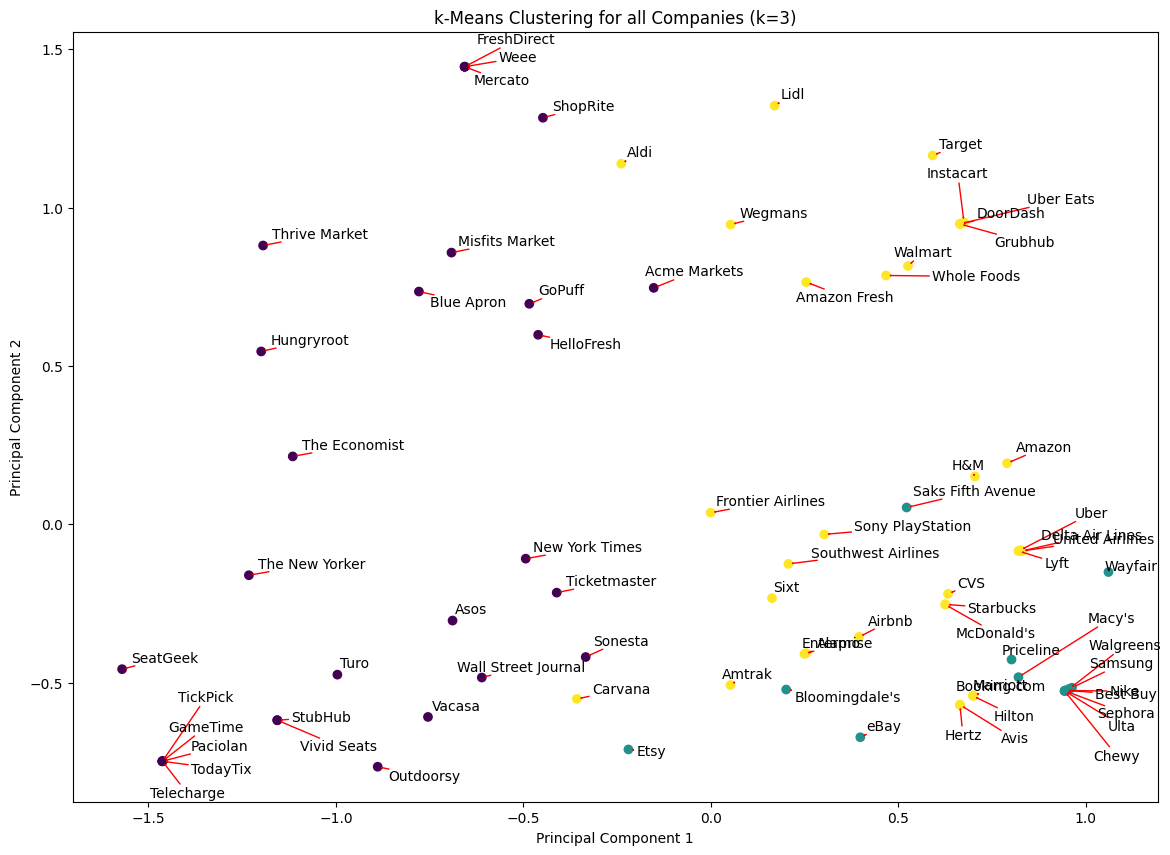

In [21]:
k_means = cluster.KMeans(n_clusters=3, max_iter=50, random_state=1)
k_means.fit(df1)
labels = k_means.labels_

pca_2_new = PCA(n_components=2)
pca_2_result_new = pca_2_new.fit_transform(df1)
print('Explained variation per principal component: {}'.format(pca_2_new.explained_variance_ratio_))

print('Cumulative variance explained by 2 principal components: {:.2%}'.format(np.sum(pca_2_new.explained_variance_ratio_)))
visualize_clusters(pca_2_result_new, labels)

Explained variation per principal component: [0.22026663 0.14797533]
Cumulative variance explained by 2 principal components: 36.82%


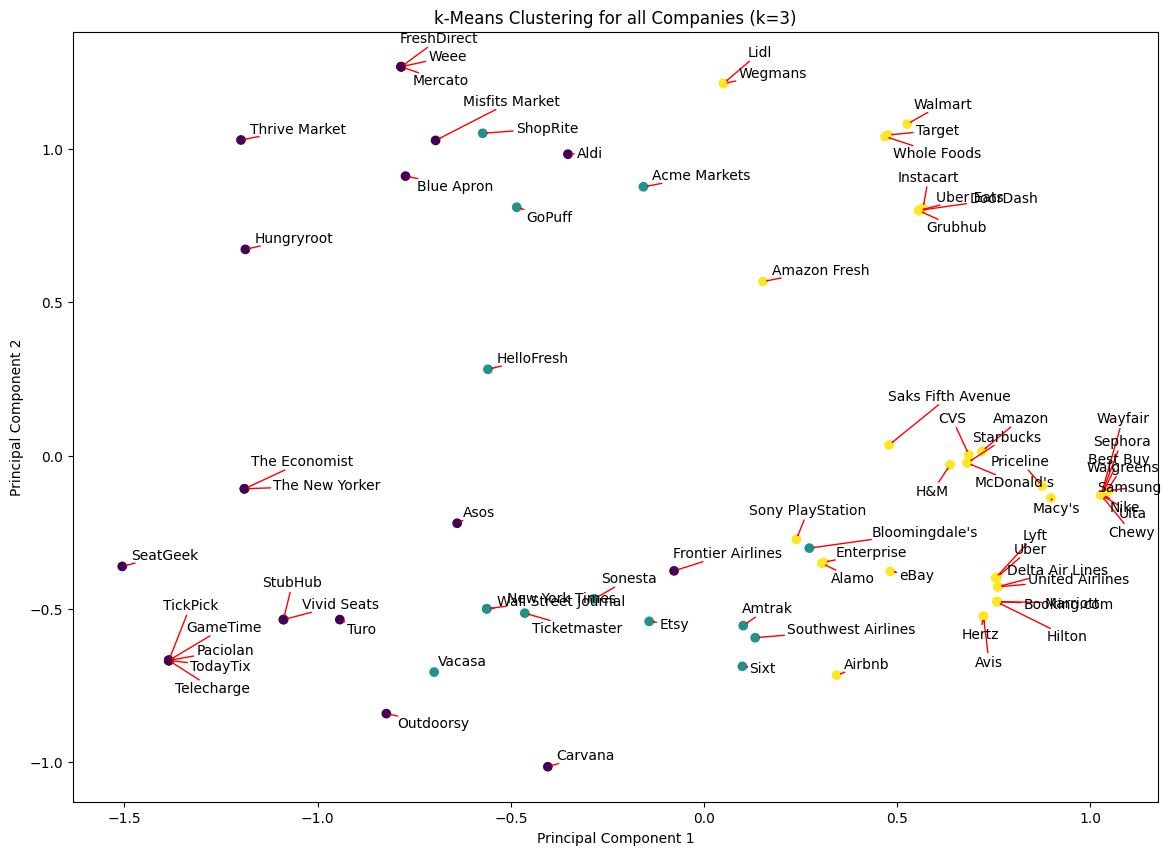

In [24]:
# remove disclosure presence column
df2 = df.drop(["company", "disclosure", 'confirmed_pricing'], axis=1)

pca_2_none = PCA(n_components=2)
pca_2_result_none = pca_2_none.fit_transform(df2)
print('Explained variation per principal component: {}'.format(pca_2_none.explained_variance_ratio_))

print('Cumulative variance explained by 2 principal components: {:.2%}'.format(np.sum(pca_2_none.explained_variance_ratio_)))

k_means = cluster.KMeans(n_clusters=3, max_iter=50, random_state=1)
k_means.fit(df2)
labels = k_means.labels_
visualize_clusters(pca_2_result_none, labels)

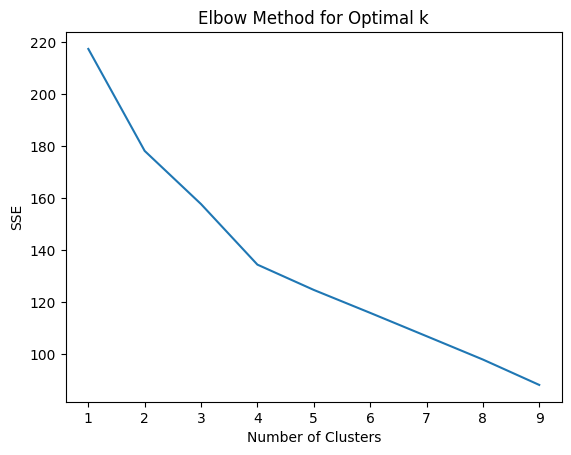

In [44]:
get_best_k_clusters(df2)

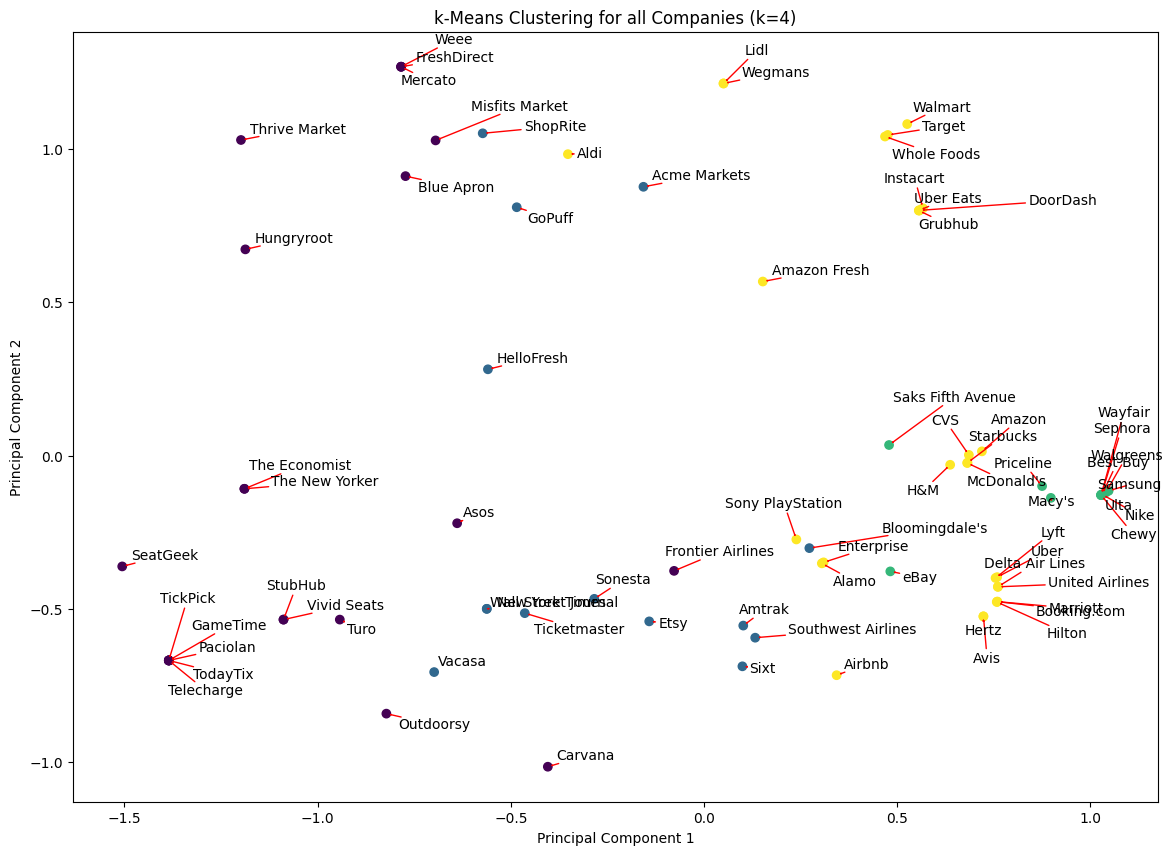

In [35]:
# for 4 clusters; compliance data excluded
k_means = cluster.KMeans(n_clusters=4, max_iter=50, random_state=1)
k_means.fit(df2)
labels = k_means.labels_
visualize_clusters(pca_2_result_none, labels)